In [1]:
import random
from typing import Tuple

import gymnasium as gym
import numpy as np


# ============================================================
# Hyperparameters
# ============================================================

ALPHA = 0.8
GAMMA = 0.95

EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.05

EPISODES = 2000
MAX_STEPS = 100


# ============================================================
# Choose Action
# ============================================================

def choose_action(
    q_table: np.ndarray,
    state: int,
    epsilon: float
) -> int:

    # Exploration
    if random.random() < epsilon:
        return random.randint(0, q_table.shape[1] - 1)

    # Exploitation
    return int(np.argmax(q_table[state]))


# ============================================================
# Train Agent
# ============================================================

def train_agent() -> Tuple[np.ndarray, gym.Env]:

    # Create FrozenLake environment
    env = gym.make(
        "FrozenLake-v1",
        is_slippery=False
    )

    # Create Q-table
    q_table = np.zeros(
        (
            env.observation_space.n,
            env.action_space.n
        )
    )

    epsilon = EPSILON

    # Training loop
    for _ in range(EPISODES):

        state, _ = env.reset()

        for _ in range(MAX_STEPS):

            # Choose action
            action = choose_action(
                q_table,
                state,
                epsilon
            )

            # Take action
            next_state, reward, terminated, truncated, _ = env.step(
                action
            )

            # Best Q-value for next state
            best_next_value = np.max(
                q_table[next_state]
            )

            # Current Q-value
            old_value = q_table[state, action]

            # Q-learning update
            q_table[state, action] = old_value + ALPHA * (
                reward
                + GAMMA * best_next_value
                - old_value
            )

            # Move to next state
            state = next_state

            # Stop if episode is finished
            if terminated or truncated:
                break

        # Reduce exploration over time
        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )

    return q_table, env


# ============================================================
# Evaluate Agent
# ============================================================

def evaluate_agent(
    q_table: np.ndarray,
    env: gym.Env
) -> None:

    action_names = {
        0: "LEFT",
        1: "DOWN",
        2: "RIGHT",
        3: "UP",
    }

    # Reset environment
    state, _ = env.reset()

    print(f"Starting state: {state}")

    for step_number in range(
        1,
        MAX_STEPS + 1
    ):

        # Select best action from Q-table
        action = int(
            np.argmax(q_table[state])
        )

        print(
            f"Step {step_number}: "
            f"State={state}, "
            f"Action={action_names[action]}"
        )

        # Take action
        next_state, reward, terminated, truncated, _ = env.step(
            action
        )

        print(
            f"    Next state={next_state}, "
            f"Reward={reward}"
        )

        # Update state
        state = next_state

        # Check whether episode has ended
        if terminated or truncated:

            if reward > 0:
                print("Agent reached the goal!")
            else:
                print("Agent failed to reach the goal.")

            break


# ============================================================
# Main
# ============================================================

def main() -> None:

    print("Training RL agent...")

    q_table, env = train_agent()

    print("\nTraining completed.")

    print("\nLearned Q-table:")
    print(q_table)

    print("\nEvaluating trained agent...")

    evaluate_agent(
        q_table,
        env
    )

    env.close()


# ============================================================
# Program Entry Point
# ============================================================

if __name__ == "__main__":
    main()

Training RL agent...

Training completed.

Learned Q-table:
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.         0.        ]
 [0.4469336  0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.         0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]

Evaluating trained agent...
Starting state: 0
Step 1: State=0, Action=DOWN
    Next state=4, Reward=0
Step 2: State=4, Action=DOWN
    Next state=8, Reward=0
Step 3: State=8, Action=RIGH

What this program is doing

The overall flow is:

FrozenLake Environment

        ↓
Initialize Q-table

        ↓
Training

        ↓
Choose Action

        ↓
Take Action

        ↓
Receive Reward

        ↓
Update Q-value

        ↓
Repeat

        ↓
Learned Q-table

        ↓
Evaluation

        ↓
Agent reaches the goal


The important Q-learning equation

This part:

q_table[state, action] = old_value + ALPHA * (
    reward
    + GAMMA * best_next_value
    - old_value
)

is the Q-learning update:

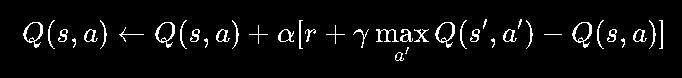

Where:

Variable    ->    	Meaning

Q(s,a)	    ->    Current Q-value

ALPHA	    ->    Learning rate

reward	    ->    Reward received

GAMMA	    ->    Discount factor

s'	    ->    Next state

max Q(s',a')->	Best future Q-value

Your FrozenLake actions

0 → LEFT

1 → DOWN

2 → RIGHT

3 → UP


The environment has 16 states and 4 actions, so the Q-table is:

q_table.shape

which will be:

(16, 4)

Conceptually:

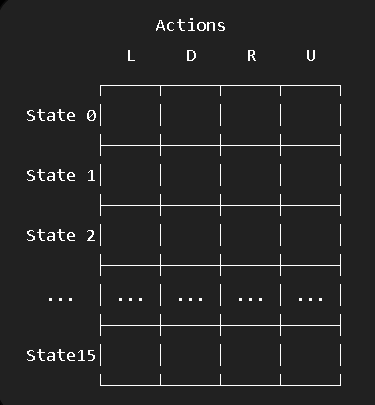

During training, those zeros gradually become learned Q-values.

Also, your FrozenLake-v1 setup uses:

is_slippery=False

which makes the environment deterministic. That is useful for learning this Q-learning example because the agent's chosen action produces predictable movement.